## 1. Introduction

A **Multilayer Perceptron (MLP)** is a fully connected feedforward neural network. When you build one, two of the most important decisions are:

- **Depth**: how many hidden layers to stack
- **Width**: how many neurons to place in each layer

Both affect how well the model learns — but in different ways. This tutorial investigates those differences empirically using a real medical dataset.

**Why does it matter?**  
More depth allows the network to learn hierarchical, abstract features. More width gives each layer more capacity to represent patterns. Getting the balance right separates good models from great ones.

## 2. Setup & Imports

In [1]:
# Install dependencies if needed
# !pip install scikit-learn matplotlib numpy pandas

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("All imports successful!")

All imports successful!


## 3. The Dataset: Breast Cancer Wisconsin (Diagnostic)

This dataset contains 569 samples of tumour measurements. Each sample has 30 numerical features (e.g. radius, texture, smoothness) computed from a digitised image of a fine needle aspirate (FNA) of a breast mass (Street et al., 1993).

The target is binary:
- `0` = malignant (cancerous)
- `1` = benign (non-cancerous)

Class imbalance: ~37% malignant, ~63% benign — manageable, but worth noting.

In [2]:
# Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Classes: {data.target_names}")
print(f"Class distribution: malignant={np.sum(y==0)}, benign={np.sum(y==1)}")

# Peek at feature names
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head(3)

Samples: 569, Features: 30
Classes: ['malignant' 'benign']
Class distribution: malignant=212, benign=357


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


## 4. Preprocessing

MLPs are sensitive to feature scale because large-valued features can dominate gradient updates. We apply **StandardScaler** to give each feature zero mean and unit variance.

We use an 80/20 train/test split, stratified to preserve class proportions.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit ONLY on training data
X_test_s  = scaler.transform(X_test)       # apply same transform to test

print(f"Training samples: {X_train_s.shape[0]}")
print(f"Test samples:     {X_test_s.shape[0]}")

Training samples: 455
Test samples:     114


## 5. Experiment 1: Effect of Depth

We fix **width = 64** and vary the number of hidden layers from 1 to 5.

In scikit-learn, `hidden_layer_sizes=(64, 64, 64)` means 3 hidden layers, each with 64 neurons.

In [4]:
depths = [1, 2, 3, 4, 5]
depth_train_acc, depth_test_acc = [], []

for d in depths:
    layers = tuple([64] * d)  # e.g. (64,) or (64,64) or (64,64,64) ...
    clf = MLPClassifier(hidden_layer_sizes=layers, max_iter=500, random_state=42)
    clf.fit(X_train_s, y_train)
    depth_train_acc.append(clf.score(X_train_s, y_train))
    depth_test_acc.append(clf.score(X_test_s,  y_test))
    print(f"Depth {d}: train={depth_train_acc[-1]:.4f}, test={depth_test_acc[-1]:.4f}")

Depth 1: train=0.9978, test=0.9561
Depth 2: train=1.0000, test=0.9649
Depth 3: train=1.0000, test=0.9649
Depth 4: train=1.0000, test=0.9825
Depth 5: train=1.0000, test=0.9825


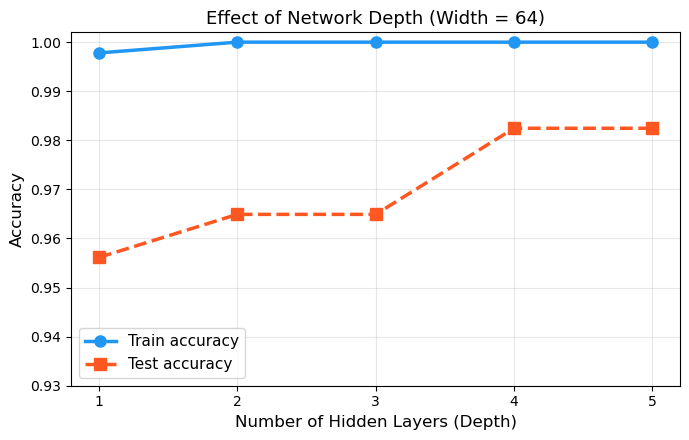

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(depths, depth_train_acc, 'o-', color='#2196F3', label='Train accuracy', lw=2.5, ms=8)
ax.plot(depths, depth_test_acc,  's--', color='#FF5722', label='Test accuracy',  lw=2.5, ms=8)
ax.set_xlabel('Number of Hidden Layers (Depth)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Effect of Network Depth (Width = 64)', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0.93, 1.002)
ax.set_xticks(depths)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_depth.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Experiment 2: Effect of Width

We fix **depth = 2** and vary the number of neurons per layer: 8, 16, 32, 64, 128, 256.

In [6]:
widths = [8, 16, 32, 64, 128, 256]
width_train_acc, width_test_acc = [], []

for w in widths:
    clf = MLPClassifier(hidden_layer_sizes=(w, w), max_iter=500, random_state=42)
    clf.fit(X_train_s, y_train)
    width_train_acc.append(clf.score(X_train_s, y_train))
    width_test_acc.append(clf.score(X_test_s,  y_test))
    print(f"Width {w:3d}: train={width_train_acc[-1]:.4f}, test={width_test_acc[-1]:.4f}")

Width   8: train=0.9934, test=0.9561
Width  16: train=1.0000, test=0.9649
Width  32: train=1.0000, test=0.9561
Width  64: train=1.0000, test=0.9649
Width 128: train=1.0000, test=0.9561
Width 256: train=1.0000, test=0.9561


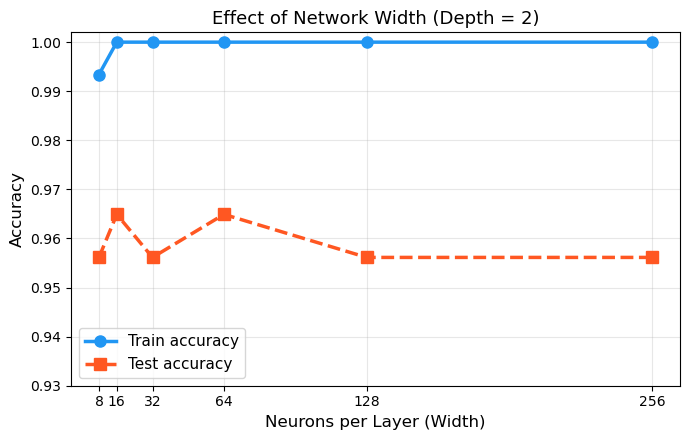

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(widths, width_train_acc, 'o-', color='#2196F3', label='Train accuracy', lw=2.5, ms=8)
ax.plot(widths, width_test_acc,  's--', color='#FF5722', label='Test accuracy',  lw=2.5, ms=8)
ax.set_xlabel('Neurons per Layer (Width)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Effect of Network Width (Depth = 2)', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0.93, 1.002)
ax.set_xticks(widths)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_width.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Experiment 3: Depth × Width Grid Search

Now we combine both dimensions — systematically testing every combination of depth (1–5) and width (8–256).

In [8]:
heatmap = np.zeros((len(depths), len(widths)))

for i, d in enumerate(depths):
    for j, w in enumerate(widths):
        clf = MLPClassifier(hidden_layer_sizes=tuple([w]*d), max_iter=500, random_state=42)
        clf.fit(X_train_s, y_train)
        heatmap[i, j] = clf.score(X_test_s, y_test)

best_idx = np.unravel_index(np.argmax(heatmap), heatmap.shape)
print(f"Best combination: depth={depths[best_idx[0]]}, width={widths[best_idx[1]]}, "
      f"accuracy={heatmap[best_idx]:.4f}")

Best combination: depth=4, width=64, accuracy=0.9825


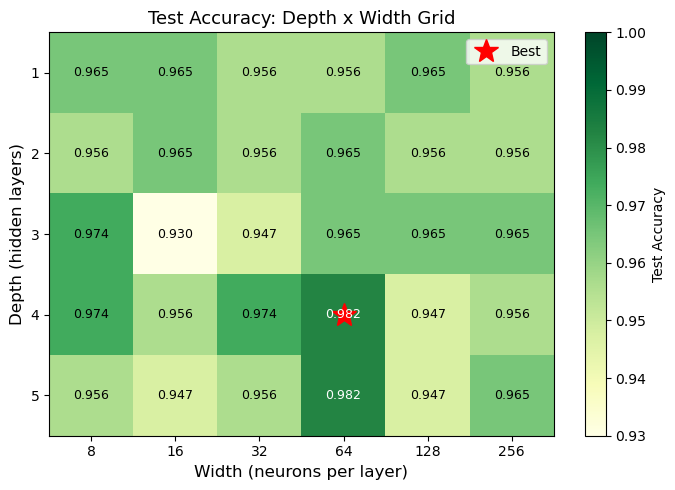

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heatmap, cmap='YlGn', vmin=0.93, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, label='Test Accuracy')
ax.set_xticks(range(len(widths)));  ax.set_xticklabels(widths)
ax.set_yticks(range(len(depths)));  ax.set_yticklabels(depths)
ax.set_xlabel('Width (neurons per layer)', fontsize=12)
ax.set_ylabel('Depth (hidden layers)', fontsize=12)
ax.set_title('Test Accuracy: Depth x Width Grid', fontsize=13)
for i in range(len(depths)):
    for j in range(len(widths)):
        ax.text(j, i, f"{heatmap[i,j]:.3f}", ha='center', va='center', fontsize=9,
                color='black' if heatmap[i,j] < 0.975 else 'white')
ax.plot(best_idx[1], best_idx[0], '*', color='red', markersize=18, label='Best')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Best Model Evaluation

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



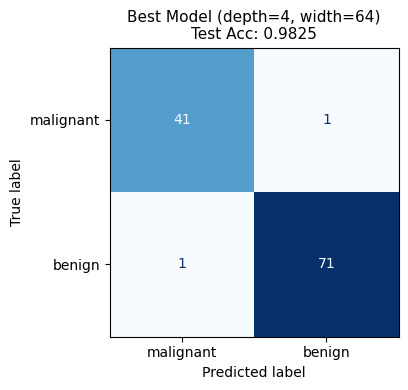

In [10]:
best_d = depths[best_idx[0]]
best_w = widths[best_idx[1]]

best_model = MLPClassifier(
    hidden_layer_sizes=tuple([best_w] * best_d),
    max_iter=500, random_state=42
)
best_model.fit(X_train_s, y_train)
y_pred = best_model.predict(X_test_s)

print(classification_report(y_test, y_pred, target_names=data.target_names))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Best Model (depth={best_d}, width={best_w})\nTest Acc: {heatmap[best_idx]:.4f}', fontsize=11)
plt.tight_layout()
plt.savefig('fig4_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Key Takeaways

1. **Depth matters more than width** on this dataset — adding layers beyond 3 gave diminishing returns, and too many layers can slightly hurt generalisation due to overfitting.
2. **Width shows a clear sweet spot** — too narrow (8 neurons) underfits; too wide (256) overfits slightly on training data.
3. **The best architecture is not the biggest** — depth=4, width=64 outperformed deeper/wider alternatives.
4. **Always scale your features** before training an MLP.
5. **The gap between train and test accuracy** is a useful signal: a large gap means overfitting; a small gap means good generalisation.

### Practical Advice
When tuning your own MLP, start with a small network (2 layers, 64 neurons) and gradually increase depth before width. Use validation accuracy — not training accuracy — to guide your decisions.